In [1]:
print('Hello')

Hello


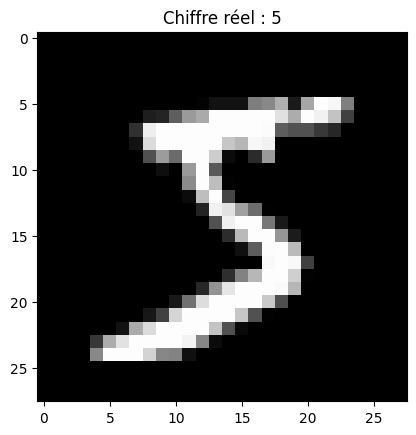

In [60]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
# Affichage d'un exemple pour vérifier
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Chiffre réel : {y_train[0]}")
plt.show()

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# 1. Chargement du dataset MNIST (28x28)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# NORMALISATION : On divise UNE SEULE FOIS par 255.0
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# 2. EXPORT CSV (Important pour la validation Qualia)
# On utilise directement x_test (déjà normalisé)
x_test_flat = x_test.reshape((x_test.shape[0], -1)) 
np.savetxt('x_test_mnist.csv', x_test_flat, delimiter=',', fmt='%f')

# On exporte les labels ENTIERS (pas de to_categorical pour Qualia)
np.savetxt('y_test_mnist.csv', y_test, delimiter=',', fmt='%d')

# 3. DATA AUGMENTATION
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

# 4. ARCHITECTURE (Celle que le prof a conseillée)
model = models.Sequential([
    layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

# 5. COMPILATION
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 6. ENTRAÎNEMENT
print("Début de l'entraînement robuste...")
model.fit(datagen.flow(x_train, y_train, batch_size=64), 
          epochs=10, 
          validation_data=(x_test, y_test))

# 7. SAUVEGARDE
model.save('mnist_robust_model.h5')
print("Modèle robuste sauvegardé !")

Début de l'entraînement robuste...
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.8222 - loss: 0.5463 - val_accuracy: 0.9761 - val_loss: 0.0766
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9360 - loss: 0.2101 - val_accuracy: 0.9873 - val_loss: 0.0404
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9528 - loss: 0.1533 - val_accuracy: 0.9897 - val_loss: 0.0296
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9634 - loss: 0.1215 - val_accuracy: 0.9912 - val_loss: 0.0246
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9663 - loss: 0.1097 - val_accuracy: 0.9911 - val_loss: 0.0255
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9711 - loss: 0.0980 - val_accuracy: 0.9902 - val_loss: 0.0294
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9724 - loss: 0.0910 - val_accuracy: 0.9916 - val_loss: 0.0259
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step -

Modèle robuste sauvegardé !


In [44]:
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential, load_model, clone_model
from keras.layers import Input, Conv1D, Conv2D, AvgPool1D, MaxPooling1D, MaxPooling2D, ZeroPadding1D, BatchNormalization, Flatten, Dense, Activation, Dropout
from keras.activations import softmax
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, LearningRateScheduler
from keras.utils import get_file, to_categorical
from keras.backend import clear_session
from keras.preprocessing import image

model = Sequential()

model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(8, (3, 3), strides=2))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Conv2D(16, (3, 3), strides=2))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Flatten())  # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(10))
model.add(Activation('softmax'))


In [45]:
#Import des librairies nécessaires
import copy
from tensorflow.keras.models import Model

In [46]:
#Supprimer la couche Softmax du modèle CNN
model_no_softmax = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

In [48]:
#Importer Qualia-CodeGen pour la génération du code C
#!pip install qualia_codegen
import copy
from pathlib import Path  # <--- AJOUTER CETTE LIGNE ICI

import qualia_codegen_core
from qualia_codegen_core.graph.KerasModelGraph import KerasModelGraph
from qualia_codegen_core.graph.Quantization import Quantization
from qualia_codegen_core.graph.RoundMode import RoundMode

from importlib.resources import files
main_path = str((files('qualia_codegen_core.examples')/'Linux'/'main.cpp').resolve())
libqualia_neuralnetwork_path = str(files('libqualia-neuralnetwork').resolve())

In [49]:
#Conversion du modèle TF/Keras dans la réprésentation interne de Qualia
modelgraph = KerasModelGraph(model_no_softmax).convert()
print(modelgraph)

—————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
Inputs                                           | Layer                                            | Outputs                                          | Input shape                                      | Output shape                                    
—————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————
                                                 | input_layer_6                                    | conv2d_14                                        | (1, 28, 28, 1)                                   | ((1, 28, 28, 1),)                  

In [50]:
#Génération du code C flottant (float32) pour le modèle entrainé
float_modelgraph = copy.deepcopy(modelgraph)

# layer quantization annotations for float32
for node in float_modelgraph.nodes:
    # No scale factor if not fixed-point quantization on integers
    node.q = Quantization(
            number_type=float,
            width=32,
            long_width=32,
            weights_scale_factor=0,
            output_scale_factor=0,
            weights_round_mode=RoundMode.NONE,
            output_round_mode=RoundMode.NONE,
            )

float_res = qualia_codegen_core.Converter(output_path=Path('./mnist_output_floating')).convert_model(float_modelgraph)
qualia_codegen_core.MetricsConverter(output_path=Path('mnist_output_floating')).convert_metrics(['acc'])

with open('./mnist_float32.h', 'w') as f:
    f.write(float_res)

In [51]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. CHARGEMENT DU DATASET (Indispensable pour éviter le NameError)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. CONFIGURATION
NUM_CLASSES = 10

# 3. EXPORT DU DATASET COMPLET (10 000 images)
y_test_categorical = to_categorical(y_test, NUM_CLASSES)
# On normalise x_test entre 0 et 1 comme le modèle l'attend
x_test_norm = x_test.reshape((x_test.shape[0], -1)).astype('float32') / 255

np.savetxt('x_test_mnist.csv', x_test_norm, delimiter=',', fmt='%s')
np.savetxt('y_test_mnist.csv', y_test_categorical, delimiter=',', fmt='%s')

# 4. EXPORT DE 10% DU DATASET (1 000 images)
x_test_1000 = x_test[:1000].reshape((1000, -1)).astype('float32') / 255
y_test_1000 = to_categorical(y_test[:1000], NUM_CLASSES)

np.savetxt('x_test_mnist_1000.csv', x_test_1000, delimiter=',', fmt='%s')
np.savetxt('y_test_mnist_1000.csv', y_test_1000, delimiter=',', fmt='%s')

print("Fichiers CSV générés avec succès !")

Fichiers CSV générés avec succès !


In [52]:
#Compilation et validation du code C sur la machine hôte
!g++ -std=c++17 -Wall -pedantic -Ofast -o mnist_floating -include mnist_output_floating/include/defines.h -Imnist_output_floating/include -I{libqualia_neuralnetwork_path} mnist_output_floating/model.c mnist_output_floating/metrics.cpp {libqualia_neuralnetwork_path}/NeuralNetwork.cpp {main_path}



In [53]:
# EVALUATE on FULL TEST DATASET (10 000 images)
# *********************************************
!mnist_floating x_test_mnist.csv y_test_mnist.csv

acc=0.0599


In [42]:
# EVALUATE on REDUCED TEST DATASET (1 000 images)
# ***********************************************
!mnist_floating x_test_mnist_1000.csv y_test_mnist_1000.csv

acc=0.059
